In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

In [3]:
# Load the biometric dataset
data = pd.read_csv("/content/biomet_data.csv", sep="\t", header=None)

# Remove completely empty columns
data = data.dropna(axis=1, how="all")

print(data.shape)

(144, 1000)


In [4]:

features = data.to_numpy(dtype=float).T

print("Shape after transpose:", features.shape)

Shape after transpose: (1000, 144)


In [5]:
# 100 users × 10 images × 144 features
user_data = features.reshape(100, 10, 144)
print("User-wise data shape:", user_data.shape)

User-wise data shape: (100, 10, 144)


In [6]:
# First 5 images of every user → training
training_data = user_data[:, :5, :]

# Last 5 images of every user → testing
testing_data = user_data[:, 5:, :]

print("Training data shape:", training_data.shape)
print("Testing data shape :", testing_data.shape)

Training data shape: (100, 5, 144)
Testing data shape : (100, 5, 144)


In [7]:
# one template for each user by averaging 5 training images

templates = training_data.mean(axis=1)

print("Template shape:", templates.shape)

Template shape: (100, 144)


In [8]:
print("User 1 template:")
print(templates[0])

print("\nNumber of features:", len(templates[0]))

User 1 template:
[248.304314 332.282754 244.365172 240.296294 218.103476 324.37328
 372.879054 303.428922 306.874064 235.823512 204.931406 180.35642
 217.648518 342.547346 259.278694 268.659924 275.730964 318.239166
 349.23912  317.24192  340.754434 260.835178 248.9363   206.115134
 171.039784 299.479012 284.811586 240.466028 251.661246 302.175132
 335.417424 363.261784 328.500492 234.890296 219.689548 194.303512
 150.583018 269.599454 321.872764 265.978046 234.743688 223.47198
 257.16046  283.920124 244.550152 215.411764 179.263496 159.248112
 174.577438 225.343716 276.412686 346.402842 321.292002 331.620044
 292.497378 237.147538 192.000018 209.628534 173.2368   140.46209
 209.411932 220.888236 226.163826 328.790038 296.699616 357.185602
 403.55307  375.946342 330.731464 292.34634  220.632994 159.284084
 251.458724 247.846746 201.70205  251.607534 256.424592 236.469654
 293.290534 298.773602 312.311894 344.635914 335.920124 299.425042
 214.121044 254.426446 272.833072 302.635608 290.

Genuine and Imposter Comparisons

In [9]:
genuine_euclidean = []
imposter_euclidean = []

genuine_cosine = []
imposter_cosine = []


for user in range(100):

    for test_image in testing_data[user]:

        # ---------- Euclidean Distance ----------
        euclidean = np.linalg.norm(
            templates - test_image,
            axis=1
        )

        # ---------- Cosine Similarity ----------
        cosine = (
            templates @ test_image
        ) / (
            np.linalg.norm(templates, axis=1)
            * np.linalg.norm(test_image)
        )

        # Genuine score
        genuine_euclidean.append(euclidean[user])
        genuine_cosine.append(cosine[user])

        # Imposter scores
        for other_user in range(100):

            if other_user != user:
                imposter_euclidean.append(euclidean[other_user])
                imposter_cosine.append(cosine[other_user])


# Convert lists to NumPy arrays
genuine_euclidean = np.array(genuine_euclidean)
imposter_euclidean = np.array(imposter_euclidean)

genuine_cosine = np.array(genuine_cosine)
imposter_cosine = np.array(imposter_cosine)


print("Genuine comparisons:", len(genuine_euclidean))
print("Imposter comparisons:", len(imposter_euclidean))

Genuine comparisons: 500
Imposter comparisons: 49500


In [10]:
print("EUCLIDEAN DISTANCE")
print("Genuine mean :", genuine_euclidean.mean())
print("Genuine std  :", genuine_euclidean.std())
print("Imposter mean:", imposter_euclidean.mean())
print("Imposter std :", imposter_euclidean.std())

print("\nCOSINE SIMILARITY")
print("Genuine mean :", genuine_cosine.mean())
print("Genuine std  :", genuine_cosine.std())
print("Imposter mean:", imposter_cosine.mean())
print("Imposter std :", imposter_cosine.std())

EUCLIDEAN DISTANCE
Genuine mean : 291.616046952752
Genuine std  : 135.45973405973285
Imposter mean: 703.8227764410127
Imposter std : 301.7917993265992

COSINE SIMILARITY
Genuine mean : 0.989501168181278
Genuine std  : 0.010956905492758193
Imposter mean: 0.9603761712110512
Imposter std : 0.018366488719033444


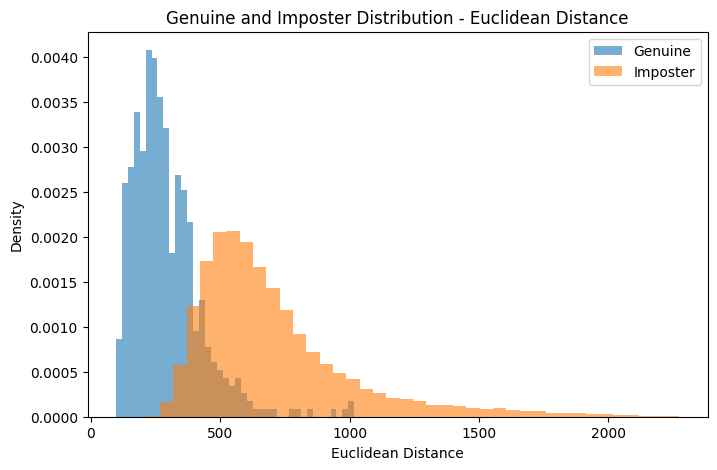

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    genuine_euclidean,
    bins=40,
    alpha=0.6,
    density=True,
    label="Genuine"
)

plt.hist(
    imposter_euclidean,
    bins=40,
    alpha=0.6,
    density=True,
    label="Imposter"
)

plt.xlabel("Euclidean Distance")
plt.ylabel("Density")
plt.title("Genuine and Imposter Distribution - Euclidean Distance")
plt.legend()

plt.show()

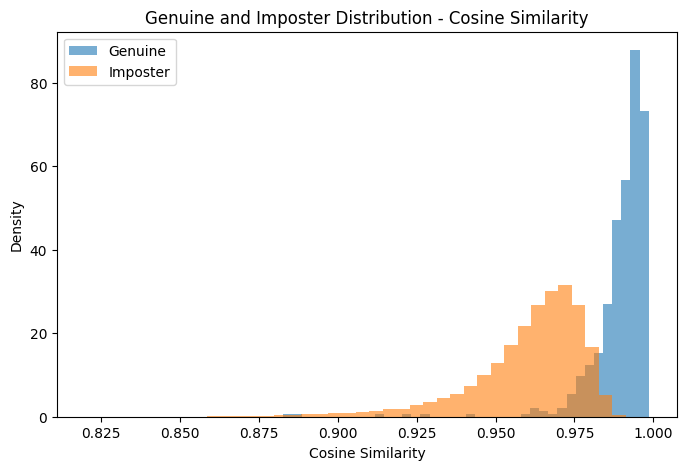

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    genuine_cosine,
    bins=40,
    alpha=0.6,
    density=True,
    label="Genuine"
)

plt.hist(
    imposter_cosine,
    bins=40,
    alpha=0.6,
    density=True,
    label="Imposter"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("Genuine and Imposter Distribution - Cosine Similarity")
plt.legend()

plt.show()

FAR and FRR for Euclidean

In [13]:
# Create thresholds
euclidean_thresholds = np.linspace(
    min(genuine_euclidean.min(), imposter_euclidean.min()),
    max(genuine_euclidean.max(), imposter_euclidean.max()),
    300
)

euclidean_far = []
euclidean_frr = []


for threshold in euclidean_thresholds:

    # Imposter accepted incorrectly
    false_accepts = np.sum(
        imposter_euclidean <= threshold
    )

    # Genuine rejected incorrectly
    false_rejects = np.sum(
        genuine_euclidean > threshold
    )

    far = false_accepts / len(imposter_euclidean)
    frr = false_rejects / len(genuine_euclidean)

    euclidean_far.append(far)
    euclidean_frr.append(frr)


euclidean_far = np.array(euclidean_far)
euclidean_frr = np.array(euclidean_frr)

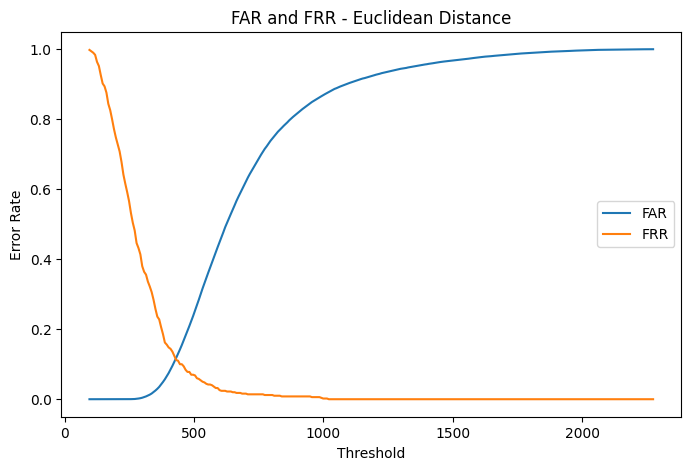

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    euclidean_thresholds,
    euclidean_far,
    label="FAR"
)

plt.plot(
    euclidean_thresholds,
    euclidean_frr,
    label="FRR"
)

plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("FAR and FRR - Euclidean Distance")
plt.legend()

plt.show()

In [15]:
cosine_thresholds = np.linspace(
    min(genuine_cosine.min(), imposter_cosine.min()),
    max(genuine_cosine.max(), imposter_cosine.max()),
    300
)

cosine_far = []
cosine_frr = []


for threshold in cosine_thresholds:

    # Imposter accepted incorrectly
    false_accepts = np.sum(
        imposter_cosine >= threshold
    )

    # Genuine rejected incorrectly
    false_rejects = np.sum(
        genuine_cosine < threshold
    )

    far = false_accepts / len(imposter_cosine)
    frr = false_rejects / len(genuine_cosine)

    cosine_far.append(far)
    cosine_frr.append(frr)


cosine_far = np.array(cosine_far)
cosine_frr = np.array(cosine_frr)

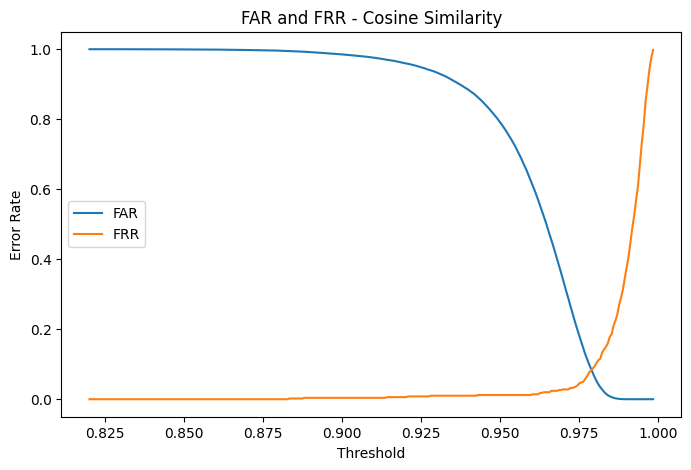

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    cosine_thresholds,
    cosine_far,
    label="FAR"
)

plt.plot(
    cosine_thresholds,
    cosine_frr,
    label="FRR"
)

plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.title("FAR and FRR - Cosine Similarity")
plt.legend()

plt.show()

In [19]:
# Labels:
# 1 = Genuine
# 0 = Imposter

labels = np.concatenate([
    np.ones(len(genuine_euclidean)),
    np.zeros(len(imposter_euclidean))
])


# ---------- Euclidean ----------

euclidean_scores = np.concatenate([
    -genuine_euclidean,
    -imposter_euclidean
])

eu_fpr, eu_tpr, eu_thresholds = roc_curve(
    labels,
    euclidean_scores
)

eu_auc = auc(eu_fpr, eu_tpr)


# ---------- Cosine ----------

cosine_scores = np.concatenate([
    genuine_cosine,
    imposter_cosine
])

co_fpr, co_tpr, co_thresholds = roc_curve(
    labels,
    cosine_scores
)

co_auc = auc(co_fpr, co_tpr)


print("Euclidean ROC-AUC:", eu_auc)
print("Cosine ROC-AUC   :", co_auc)

Euclidean ROC-AUC: 0.9495562424242423
Cosine ROC-AUC   : 0.9689432323232323


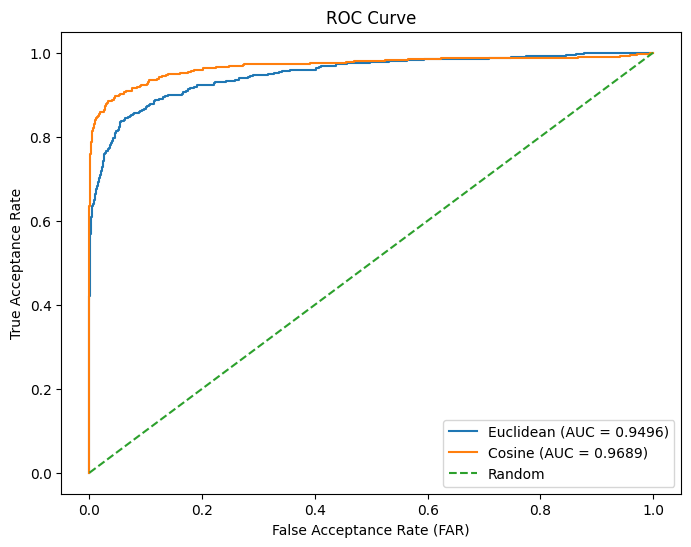

In [20]:
plt.figure(figsize=(8, 6))

plt.plot(
    eu_fpr,
    eu_tpr,
    label=f"Euclidean (AUC = {eu_auc:.4f})"
)

plt.plot(
    co_fpr,
    co_tpr,
    label=f"Cosine (AUC = {co_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random"
)

plt.xlabel("False Acceptance Rate (FAR)")
plt.ylabel("True Acceptance Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

calculate EER

In [21]:
# ---------- Euclidean EER ----------

euclidean_frr_roc = 1 - eu_tpr

euclidean_difference = np.abs(
    eu_fpr - euclidean_frr_roc
)

euclidean_eer_index = np.argmin(
    euclidean_difference
)

euclidean_eer = (
    eu_fpr[euclidean_eer_index]
    + euclidean_frr_roc[euclidean_eer_index]
) / 2


# ---------- Cosine EER ----------

cosine_frr_roc = 1 - co_tpr

cosine_difference = np.abs(
    co_fpr - cosine_frr_roc
)

cosine_eer_index = np.argmin(
    cosine_difference
)

cosine_eer = (
    co_fpr[cosine_eer_index]
    + cosine_frr_roc[cosine_eer_index]
) / 2


print("Euclidean EER:", euclidean_eer)
print("Cosine EER   :", cosine_eer)

Euclidean EER: 0.11555555555555555
Cosine EER   : 0.08461616161616159


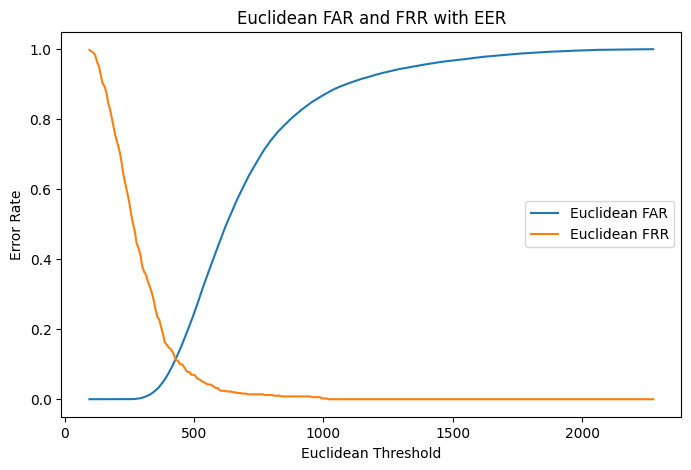

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    euclidean_thresholds,
    euclidean_far,
    label="Euclidean FAR"
)

plt.plot(
    euclidean_thresholds,
    euclidean_frr,
    label="Euclidean FRR"
)

plt.xlabel("Euclidean Threshold")
plt.ylabel("Error Rate")
plt.title("Euclidean FAR and FRR with EER")
plt.legend()

plt.show()

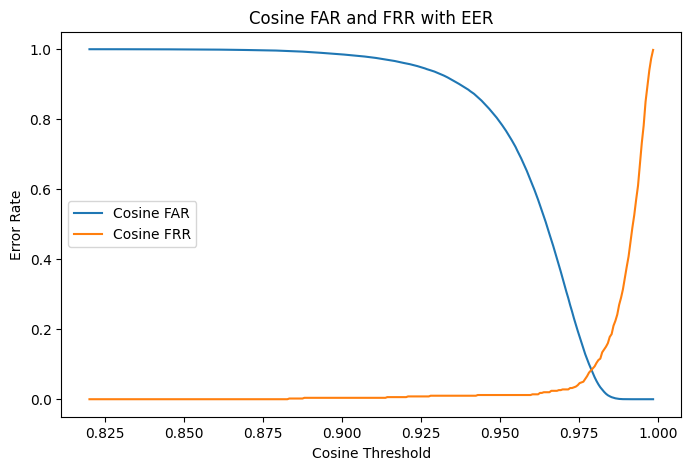

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    cosine_thresholds,
    cosine_far,
    label="Cosine FAR"
)

plt.plot(
    cosine_thresholds,
    cosine_frr,
    label="Cosine FRR"
)

plt.xlabel("Cosine Threshold")
plt.ylabel("Error Rate")
plt.title("Cosine FAR and FRR with EER")
plt.legend()

plt.show()

In [24]:
# ---------- Euclidean ----------

euclidean_genuine_mean = genuine_euclidean.mean()
euclidean_imposter_mean = imposter_euclidean.mean()

euclidean_genuine_std = genuine_euclidean.std()
euclidean_imposter_std = imposter_euclidean.std()

euclidean_dprime = abs(
    euclidean_genuine_mean - euclidean_imposter_mean
) / np.sqrt(
    (euclidean_genuine_std**2 +
     euclidean_imposter_std**2) / 2
)


# ---------- Cosine ----------

cosine_genuine_mean = genuine_cosine.mean()
cosine_imposter_mean = imposter_cosine.mean()

cosine_genuine_std = genuine_cosine.std()
cosine_imposter_std = imposter_cosine.std()

cosine_dprime = abs(
    cosine_genuine_mean - cosine_imposter_mean
) / np.sqrt(
    (cosine_genuine_std**2 +
     cosine_imposter_std**2) / 2
)


print("Euclidean Decidability Index:", euclidean_dprime)
print("Cosine Decidability Index   :", cosine_dprime)

Euclidean Decidability Index: 1.7622461862707728
Cosine Decidability Index   : 1.9259344481978724


In [25]:
results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "EER",
        "Decidability Index"
    ],

    "Euclidean": [
        eu_auc,
        euclidean_eer,
        euclidean_dprime
    ],

    "Cosine": [
        co_auc,
        cosine_eer,
        cosine_dprime
    ]
})

results

,Metric,Euclidean,Cosine
0,ROC-AUC,0.949556,0.968943
1,EER,0.115556,0.084616
2,Decidability Index,1.762246,1.925934


In [26]:
print("FINAL COMPARISON")
print("================")

print(f"Euclidean ROC-AUC       : {eu_auc:.4f}")
print(f"Cosine ROC-AUC          : {co_auc:.4f}")

print(f"\nEuclidean EER           : {euclidean_eer:.4f}")
print(f"Cosine EER              : {cosine_eer:.4f}")

print(f"\nEuclidean Decidability  : {euclidean_dprime:.4f}")
print(f"Cosine Decidability     : {cosine_dprime:.4f}")


if (
    co_auc > eu_auc
    and cosine_eer < euclidean_eer
    and cosine_dprime > euclidean_dprime
):
    print("\nConclusion: Cosine similarity performs better overall.")

elif (
    eu_auc > co_auc
    and euclidean_eer < cosine_eer
    and euclidean_dprime > cosine_dprime
):
    print("\nConclusion: Euclidean distance performs better overall.")

else:
    print("\nConclusion: The results are mixed, so all metrics should be considered.")

FINAL COMPARISON
Euclidean ROC-AUC       : 0.9496
Cosine ROC-AUC          : 0.9689

Euclidean EER           : 0.1156
Cosine EER              : 0.0846

Euclidean Decidability  : 1.7622
Cosine Decidability     : 1.9259

Conclusion: Cosine similarity performs better overall.
